# 딥러닝의 기본 이미지 분류하기
## 흉부 엑스레이 분석과 데이터 증강하기

In [1]:
import os
from pathlib import Path
import random


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
from torch import nn,optim
from torchvision import  datasets, models
import  torchvision.transforms.v2  as transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from collections import OrderedDict
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

seed = 1010
random.seed(seed)         # python seed
np.random.seed(seed)      # numpy seed
torch.manual_seed(seed)   # torch seed


cpu


### 1 데이터셋

In [2]:


print("Train")
print("NORMAL:", len(os.listdir("data/chest_xray/train/NORMAL")), end=', ')
print("PNEUMONIA:", len(os.listdir("data/chest_xray/train/PNEUMONIA")))
print()
print("Validation")
print("NORMAL:", len(os.listdir("data/chest_xray/val/NORMAL")), end=', ')
print("PNEUMONIA:", len(os.listdir("data/chest_xray/val/PNEUMONIA")))
print()
print("Test")
print("NORMAL:", len(os.listdir("data/chest_xray/test/NORMAL")), end=', ')
print("PNEUMONIA:", len(os.listdir("data/chest_xray/test/PNEUMONIA")))

Train
NORMAL: 1341, PNEUMONIA: 3875

Validation
NORMAL: 8, PNEUMONIA: 8

Test
NORMAL: 234, PNEUMONIA: 390


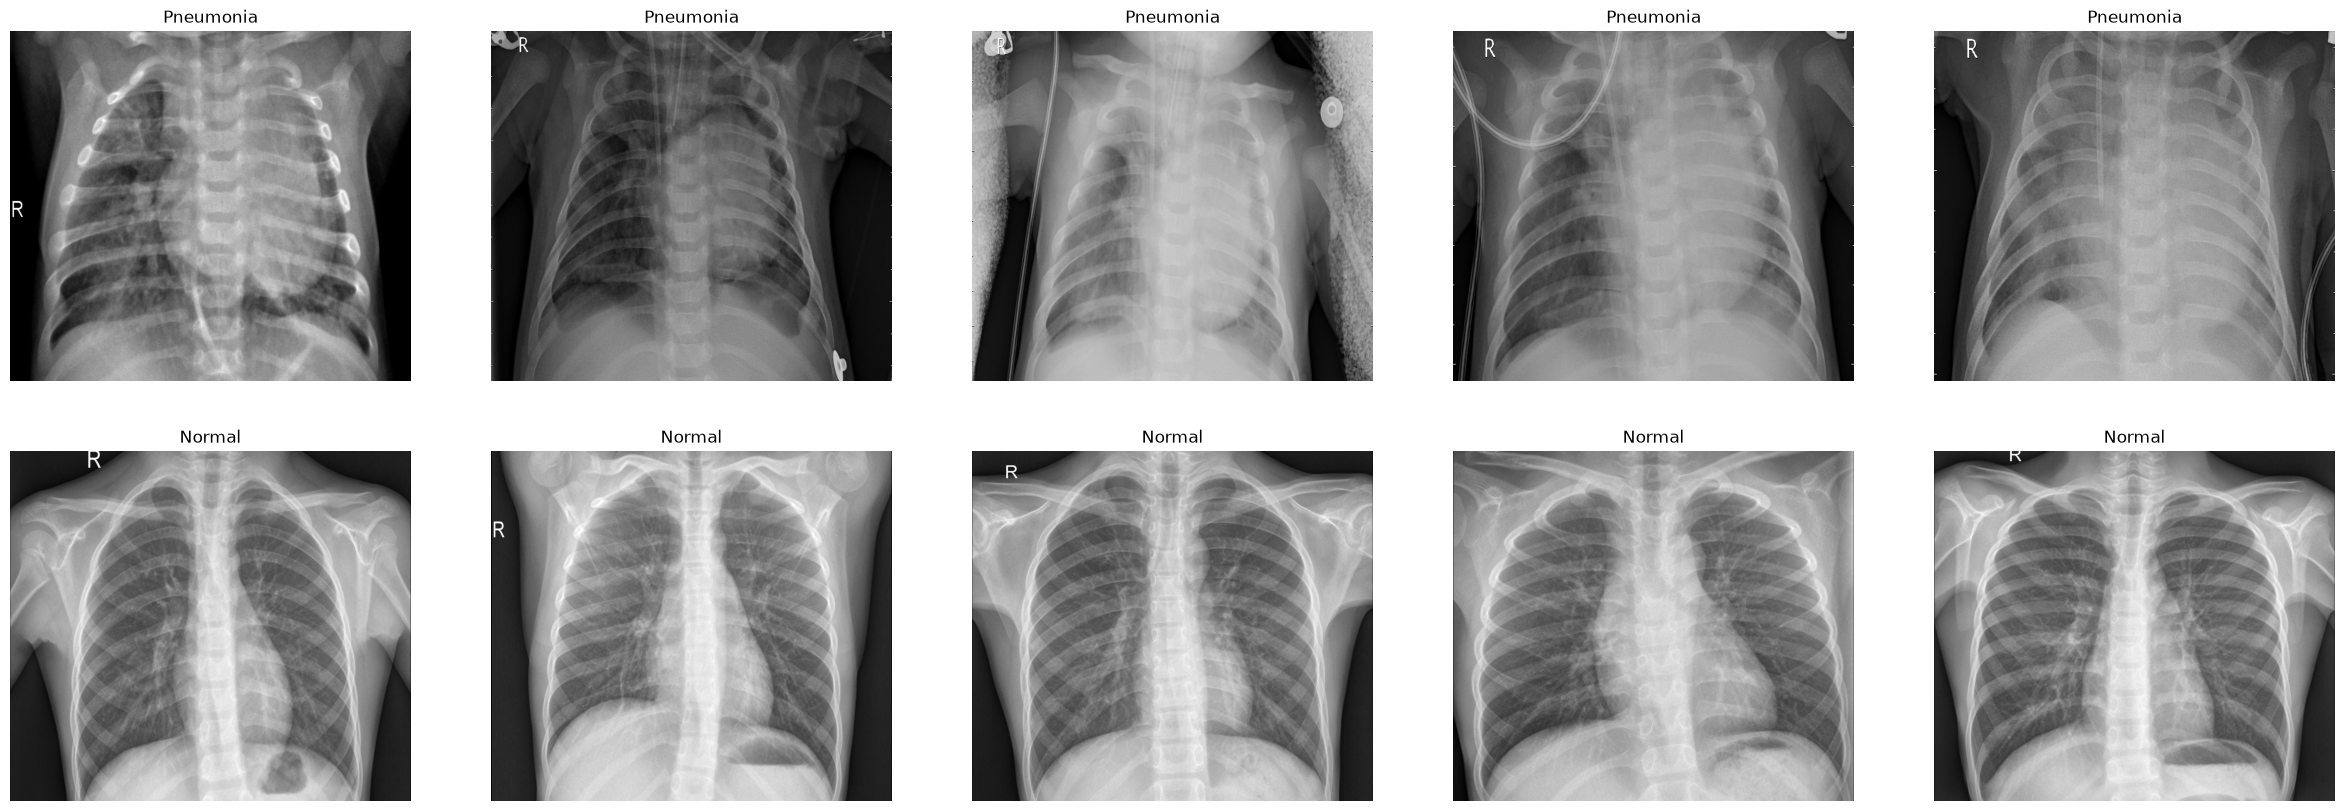

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

root = "data/chest_xray/test/"
normal_dir = root + 'NORMAL/'
pneumonia_dir = root + 'PNEUMONIA/'

normal = list(map(lambda x: normal_dir+x, os.listdir(normal_dir)[:5]))
pneumonia = list(map(lambda x: pneumonia_dir+x, os.listdir(pneumonia_dir)[:5]))

samples = pneumonia + normal

# show samples
plt.figure(figsize=(30,10))
for i in range(10):
  plt.subplot(2, 5, i+1)
  img = Image.open(samples[i])

  ax = plt.gca()
  ax.set_title("Pneumonia" if i < 5 else "Normal")
  ax.imshow(img, cmap='gray')
  ax.axis('off')
  ax.set_aspect('auto')
plt.show()

#### 이미지 폴더(ImageFolder)

In [4]:
def get_dataset(
    root="data/chest_xray", val=0.1,
    train_transforms=None, test_transforms=None
):
  origin = datasets.ImageFolder(
      os.path.join(root, 'train'),
      transform=train_transforms
  )

  val_samples = int(len(origin) * val)
  train_samples = len(origin) - val_samples

  trainset, valset = torch.utils.data.random_split(
    origin,
    (train_samples, val_samples),
  )
  valset.transforms = test_transforms

  testset = datasets.ImageFolder(
      os.path.join(root, 'test'),
      transform=test_transforms
  )
  return trainset, valset, testset


transform = transforms.Compose([transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)])

trainset, valset, testset = get_dataset(train_transforms= transform)
print(len(trainset), len(valset), len(testset))

4695 521 624


In [5]:
class_names = trainset.dataset.classes
print(class_names)
print(trainset.dataset.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
image, label = trainset[0]

print(image.shape)
print(label)

torch.Size([3, 928, 1310])
1


### 2 데이터 증강과 Albumentation

In [37]:
# !uv add opencv-python
# !uv add albumentations

In [7]:
import cv2
from torchvision.datasets import ImageFolder
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [8]:
# 이미지 전처리를 파이프라인으로 구현

train_transform = transforms.Compose([
    # 1. 원본 이미지의 크기를 256x256 픽셀로 조정 (해상도 통일)
    transforms.Resize((256, 256)),
    
    # 2. -20도에서 +20도 사이의 임의의 각도로 이미지를 무작위 회전 (데이터 증강)
    # * X-ray 특성상 환자가 미세하게 기울어져 촬영된 상황을 시뮬레이션하는 효과가 있습니다.
    transforms.RandomRotation(degrees=(-20, +20)),
    
    # 3. 256x256 크기로 커진 이미지에서 무작위로 224x224 영역을 잘라냄 (데이터 증강)
    # * 모델이 객체의 위치 변화에 둔감해지도록 유도하며, 최종 입력 크기를 224x224로 맞춥니다.
    transforms.RandomCrop((224, 224)),
    
    # 4. PIL 이미지나 NumPy 배열을 파이토치 텐서(Tensor)로 변환
    # * 이 과정에서 0~255 사이의 픽셀 값이 0.0~1.0의 실수 값으로 자동 정규화(Scaling)됩니다.
    transforms.ToTensor(),
    
    # 5. 첫 번째 인자(평균), 두 번째 인자(표준편차)를 사용해 데이터 정규화(Normalization)
    # * ImageNet 데이터셋의 통계치를 활용해 데이터 분포를 제로 센터링(Zero-centering)합니다.
    # * 이 정규화는 모델의 학습 속도를 높이고, 경사하강법(Gradient Descent)이 안정적으로 수렴하도록 돕습니다.
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


trainset, _, _ = get_dataset(
  train_transforms=train_transform,
)

train_loader = DataLoader(
  dataset=trainset,
  shuffle=True,
  batch_size=64,
  num_workers=0,
)

for i in tqdm(train_loader):
  pass


c:\sk-encoa\dl-workspace\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 74/74 [01:16<00:00,  1.04s/it]


In [9]:
import cv2
from torchvision.datasets import ImageFolder

class AlbumentationsDataset(ImageFolder):
    """
    torchvision의 ImageFolder를 상속받아 
    Albumentations 전처리/증강 파이프라인을 적용할 수 있도록 재정의한 커스텀 Dataset 클래스
    """

    def __getitem__(self, index: int):
        # 1. 주어진 인덱스에 해당하는 이미지 파일 경로(path)와 클래스 라벨(target) 가져오기
        path, target = self.samples[index]

        # 2. OpenCV를 이용해 이미지 읽기 (기본 BGR 채널)
        image = cv2.imread(path)
        
        # 3. Albumentations 및 PyTorch 표준에 맞게 BGR을 RGB 채널로 변환
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 4. Albumentations Transform(증강 파이프라인) 적용
        if self.transform is not None:
            # Albumentations는 키워드 인자(image=...) 형태로 입력을 받음
            augmented = self.transform(image=image)
            # 결과 딕셔너리에서 변환된 이미지(Tensor 또는 NumPy) 추출
            image = augmented['image']

        # 5. 최종 변환된 이미지와 라벨 반환
        return image, target

In [10]:
def get_dataset_v2(root="data/chest_xray", val=0.1, train_transforms=None, test_transforms=None):
  origin = AlbumentationsDataset(os.path.join(root, 'train'), transform=train_transforms)

  val_samples = int(len(origin) * val)
  train_samples = len(origin) - val_samples

  trainset, valset = torch.utils.data.random_split(
    origin,
    (train_samples, val_samples),
  )
  valset.transforms = test_transforms

  testset = AlbumentationsDataset(os.path.join(root, 'test'), transform=test_transforms)
  return trainset, valset, testset

trainset, valset, testset = get_dataset_v2(train_transforms=None)
print(len(trainset), len(valset), len(testset))

4695 521 624


In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
        A.Resize(256, 256),
        A.Rotate(limit=(-20, +20)),
        A.RandomCrop(224, 224),
        A.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
        ToTensorV2(),
])

trainset, _, _ = get_dataset_v2(
  train_transforms=train_transform,
)

train_loader = DataLoader(
  dataset=trainset,
  shuffle=True,
  batch_size=64,
  num_workers=0,
)

for i in tqdm(train_loader):
    pass

100%|██████████| 74/74 [00:48<00:00,  1.53it/s]


#### Albumentation만의 특별한 기능

In [12]:
test_transform = A.Compose([
    # 1. 이미지를 256x256 크기로 리사이즈
    A.Resize(256, 256),

    # 2. 아래 3가지 기하학적 변환 중 '하나'를 100% 확률(p=1)로 선택하여 적용
    A.OneOf([
        A.HorizontalFlip(p=1),   # 좌우 반전
        A.RandomRotate90(p=1),   # 90도 단위 무작위 회전 (90°, 180°, 270°)
        A.VerticalFlip(p=1)      # 상하 반전
    ], p=1),

    # 3. 이미지의 중앙을 기준으로 224x224 크기로 잘라냄
    A.CenterCrop(224, 224),

    # 4. 아래 3가지 노이즈/왜곡 변환 중 '하나'를 50% 확률(p=0.5)로 선택하여 적용
    A.OneOf([
        A.MotionBlur(p=0.3),         # 피사체가 흔들린 듯한 모션 블러 효과
        A.OpticalDistortion(p=0.4),  # 카메라 렌즈 상의 광학 왜곡 효과
        A.GaussNoise(p=0.5)          # 가우시안 노이즈(노이즈 입자) 추가
    ], p=0.5),

    # 5. NumPy 배열(HWC 형식)을 PyTorch Tensor(CHW 형식)로 변환
    ToTensorV2(),
])

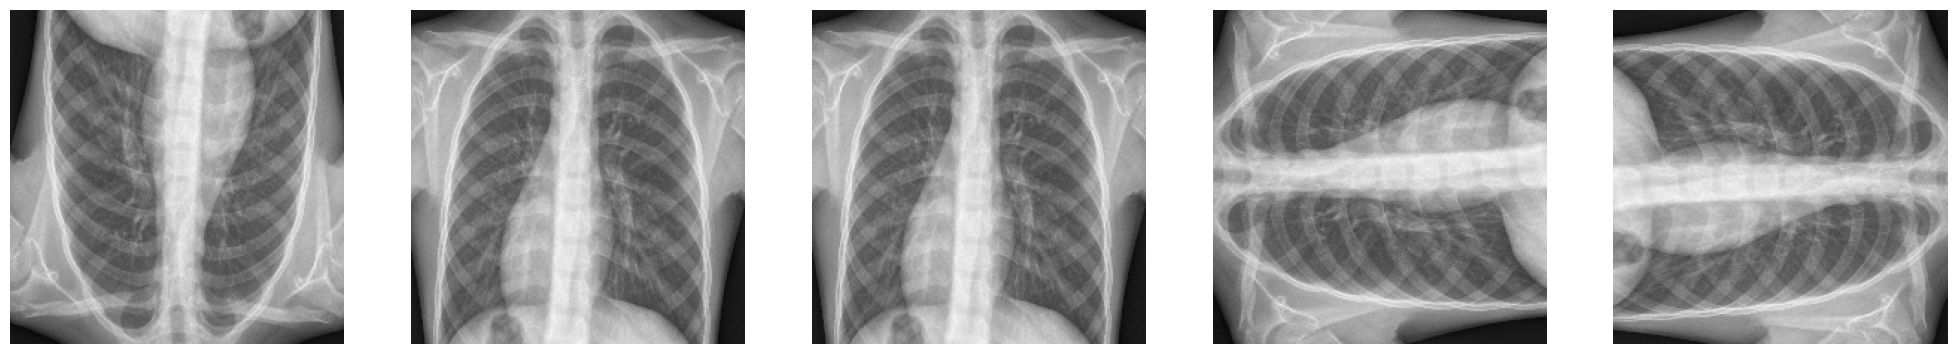

In [13]:
data_dir = Path("data/chest_xray/")
testset = AlbumentationsDataset(data_dir / 'test', transform=test_transform)

num_samples = 5
fig, ax = plt.subplots(1, num_samples, figsize=(25, 5))
for i in range(num_samples):
  ax[i].imshow(transforms.ToPILImage()(testset[0][0]))
  ax[i].axis('off')

### 3 학습 모델(ResNet18)

In [14]:
import torchvision.models as models
from torchvision.models.resnet import ResNet18_Weights

model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [15]:
def load_resnet():
  model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
  model.fc = nn.Linear(in_features=512, out_features=1, bias=True)  ###

  return model

### 4. 학습 

In [16]:
def train(model, dataloader, criterion, optimizer, epoch, device):
  # train mode
  model.train()

  # 학습 통계
  running_loss = 0
  correct = 0

  with tqdm(dataloader) as pbar:
    for i, (data, targets) in enumerate(pbar):
      data, targets = data.to(device), targets.to(device)

      optimizer.zero_grad()
      outputs = model(data)
      print(f'outputs:{outputs.shape}')
      print(f'targets:{targets.shape}')
     


      loss = criterion(outputs, targets.unsqueeze(1).float()) #### Change
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      pbar.set_postfix(loss=loss.item())

      # Accuracy 계산
      with torch.no_grad():
        predicted = torch.sigmoid(outputs).round() #### Change
        correct += predicted.eq(targets.view_as(predicted)).sum()

    # Accuracy 출력
    data_num = len(dataloader.dataset)
    acc = 100. * correct / data_num
    print(
        f"[{epoch}/{EPOCH}]",
        f"train loss: {running_loss/len(dataloader):.4f}",
        f"train acc: {correct}/{data_num} ({acc:.2f}%)"
    )

  return running_loss/len(dataloader), acc

In [17]:
EPOCH = 10
def validation(model, dataloader, criterion, epoch, device):
  # eval 모드
  model.eval()

  # 검증 통계
  correct = 0
  running_loss = 0.

  with tqdm(dataloader) as pbar:
    with torch.no_grad():
      for i, (data, targets) in enumerate(pbar):
        data, targets = data.to(device), targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets.unsqueeze(1).float())  #### Change

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

        # Accuracy 계산
        predicted = torch.sigmoid(outputs).round() #### Change
        correct += predicted.eq(targets.view_as(predicted)).sum()

  # Accuracy 계산
  data_num = len(dataloader.dataset)
  acc = 100. * correct / data_num
  print(f'[{epoch}/{EPOCH}] valid loss: {running_loss/len(dataloader):.4f} valid acc: {correct}/{data_num} ({acc:.2f}%)\n')

  return running_loss/len(dataloader), acc

In [18]:
def test(model, dataloader, device):
    # eval 모드
    model.eval()

    # 테스트 통계
    correct = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
      for data, targets in dataloader:
        data, targets = data.to(device), targets.to(device)

        outputs = model(data)    # forward

        # Accuracy 계산
        predicted = torch.sigmoid(outputs).round()  ### Change
        correct += predicted.eq(targets.view_as(predicted)).sum()

        y_true.append(targets)
        y_pred.append(outputs)

    # Accuracy 계산
    data_num = len(dataloader.dataset)
    print(f'Test Accuracy: {correct}/{data_num} ({100. * correct / data_num:.2f}%)')

    return 100. * correct / data_num, torch.cat(y_true), torch.cat(y_pred)

In [19]:


EPOCH = 10
BATCH_SIZE = 256
NUM_WORKERS = 0
LR = 0.001

print("=== Hyperparameters ===")
print(f"LR: {LR} | Epochs: {EPOCH} | Batch Size: {BATCH_SIZE} | Num Workers: {NUM_WORKERS}")
print("=" * 25)

train_transform = A.Compose([
    A.Resize(256, 256),
    A.Rotate(limit=(-20, +20)),
    A.RandomCrop(224, 224),
    A.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
    ToTensorV2(),
])
test_transform = A.Compose([
    A.Resize(256, 256),
    A.CenterCrop(224, 224),
    A.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

trainset, valset, testset = get_dataset_v2(
    train_transforms=train_transform,
    test_transforms=test_transform
)

# dataloader
train_loader = DataLoader(
    dataset=trainset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    dataset=valset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    dataset=testset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# Model
model = load_resnet()

# Optimizer, Loss, Scheduler
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=3, gamma=0.5)

model = model.to(device)
criterion = criterion.to(device)

max_acc = 0

# Start Training
for epoch in range(EPOCH):
    current_lr = scheduler.get_last_lr()[0]

    tloss, tacc = train(model, train_loader, criterion, optimizer, epoch, device)
    vloss, vacc = validation(model, val_loader, criterion, epoch, device)

    print(f"Epoch [{epoch+1:02d}/{EPOCH:02d}] | LR: {current_lr:.6f} | "
          f"Train Loss: {tloss:.4f}, Train Acc: {tacc:.2f}% | "
          f"Val Loss: {vloss:.4f}, Val Acc: {vacc:.2f}%")

    if vacc > max_acc:
        max_acc = vacc
        torch.save(model.state_dict(), "best.pth")
        print(f"  --> Best model saved (Val Acc: {vacc:.2f}%)")

    scheduler.step()

# Load best model
model.load_state_dict(torch.load("best.pth"))

# Test
tacc, y_true, y_preds = test(model, test_loader, device)
class_names = testset.classes

# Predict processing
preds_binary = torch.sigmoid(y_preds).squeeze().round().int().cpu().numpy()
y_true_np = y_true.cpu().numpy() if isinstance(y_true, torch.Tensor) else y_true

print("\n" + "=" * 10 + " Test Results " + "=" * 10)
print(f"Test Accuracy: {tacc:.2f}%\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_true_np, preds_binary)
print(cm)

print("\nClassification Report:")
print(classification_report(y_true_np, preds_binary, target_names=class_names))

=== Hyperparameters ===
LR: 0.001 | Epochs: 10 | Batch Size: 256 | Num Workers: 0


  0%|          | 0/19 [00:00<?, ?it/s]

outputs:torch.Size([256, 1])
targets:torch.Size([256])


  5%|▌         | 1/19 [00:27<08:22, 27.92s/it, loss=0.609]

outputs:torch.Size([256, 1])
targets:torch.Size([256])


...

outputs:torch.Size([87, 1])
targets:torch.Size([87])


100%|██████████| 19/19 [06:29<00:00, 20.47s/it, loss=0.00307]


[9/10] train loss: 0.0060 train acc: 4689/4695 (99.87%)


100%|██████████| 3/3 [00:16<00:00,  5.59s/it, loss=0.00448]


[9/10] valid loss: 0.0258 valid acc: 511/521 (98.08%)

Epoch [10/10] | LR: 0.000125 | Train Loss: 0.0060, Train Acc: 99.87% | Val Loss: 0.0258, Val Acc: 98.08%
Test Accuracy: 496/624 (79.49%)

========== Test Results ==========
Test Accuracy: 79.49%

Confusion Matrix:
[[107 127]
 [  1 389]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.46      0.63       234
   PNEUMONIA       0.75      1.00      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.73      0.74       624
weighted avg       0.84      0.79      0.77       624

